# Ensemble Models for Regression - Wage Prediction

This notebook explores using VotingRegressor to predict hourly wages from census data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import VotingRegressor
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Load dataset (use /tmp for caching to avoid permission issues)
survey = fetch_openml(data_id=534, as_frame=True, data_home='/tmp/scikit_learn_data').frame

# Drop rows with missing values
survey = survey.dropna()

print(f"Dataset shape: {survey.shape}")
print(f"Columns: {survey.columns.tolist()}")
print(survey.head())

Dataset shape: (534, 11)
Columns: ['EDUCATION', 'SOUTH', 'SEX', 'EXPERIENCE', 'UNION', 'WAGE', 'AGE', 'RACE', 'OCCUPATION', 'SECTOR', 'MARR']
   EDUCATION SOUTH     SEX  EXPERIENCE       UNION  WAGE  AGE      RACE  \
0          8    no  female          21  not_member  5.10   35  Hispanic   
1          9    no  female          42  not_member  4.95   57     White   
2         12    no    male           1  not_member  6.67   19     White   
3         12    no    male           4  not_member  4.00   22     White   
4         12    no    male          17  not_member  7.50   35     White   

  OCCUPATION         SECTOR       MARR  
0      Other  Manufacturing    Married  
1      Other  Manufacturing    Married  
2      Other  Manufacturing  Unmarried  
3      Other          Other  Unmarried  
4      Other          Other    Married  


In [2]:
# Prepare features and target
# Check if 'wage' or 'WAGE' column exists (case-insensitive)
cols_lower = {c.lower(): c for c in survey.columns}
if 'wage' in cols_lower:
    target_col = cols_lower['wage']
elif 'class' in cols_lower:
    target_col = cols_lower['class']
else:
    # Use the last column as target
    target_col = survey.columns[-1]

print(f"Using target column: {target_col}")

X = survey.drop(target_col, axis=1)
y = survey[target_col]

# Convert target to numeric if needed
if not pd.api.types.is_numeric_dtype(y):
    y = pd.to_numeric(y, errors='coerce')

# Select only numeric features
X = X.select_dtypes(include=[np.number])

# Drop rows with NaN
mask = X.notna().all(axis=1) & y.notna()
X = X[mask]
y = y[mask]

print(f"After cleaning: {X.shape[0]} samples")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Features: {X.columns.tolist()}")

Using target column: WAGE
After cleaning: 534 samples
Training set: 427 samples
Test set: 107 samples
Features: ['EDUCATION', 'EXPERIENCE', 'AGE']


In [3]:
# Define individual regressors
lr = LinearRegression()
ridge = Ridge()
knn = KNeighborsRegressor()
dt = DecisionTreeRegressor(random_state=42)
svr = SVR()

# Evaluate individual models
print("Individual Model Performance (MSE):")
print("-" * 40)

models = {
    'LinearRegression': lr,
    'Ridge': ridge,
    'KNeighbors': knn,
    'DecisionTree': dt,
    'SVR': svr
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name:20} MSE: {mse:10.2f}  R²: {r2:.4f}")

Individual Model Performance (MSE):
----------------------------------------
LinearRegression     MSE:      22.91  R²: 0.2815
Ridge                MSE:      22.91  R²: 0.2815
KNeighbors           MSE:      27.97  R²: 0.1225
DecisionTree         MSE:      35.29  R²: -0.1071
SVR                  MSE:      25.48  R²: 0.2006


In [4]:
# Create VotingRegressor with all models
voting_reg = VotingRegressor([
    ('lr', lr),
    ('ridge', ridge),
    ('knn', knn),
    ('dt', dt),
    ('svr', svr)
])

# Train and evaluate
voting_reg.fit(X_train, y_train)
y_pred_voting = voting_reg.predict(X_test)
mse_voting = mean_squared_error(y_test, y_pred_voting)
r2_voting = r2_score(y_test, y_pred_voting)

print(f"\nVotingRegressor MSE: {mse_voting:.2f}")
print(f"VotingRegressor R²: {r2_voting:.4f}")


VotingRegressor MSE: 24.75
VotingRegressor R²: 0.2236


In [5]:
# Feature importance using permutation importance
print("\nFeature Importance (Permutation):")
print("-" * 40)

result = permutation_importance(voting_reg, X_test, y_test, n_repeats=10, random_state=42)
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importance)


Feature Importance (Permutation):
----------------------------------------
      feature  importance
0   EDUCATION    0.330979
1  EXPERIENCE    0.018469
2         AGE    0.007175


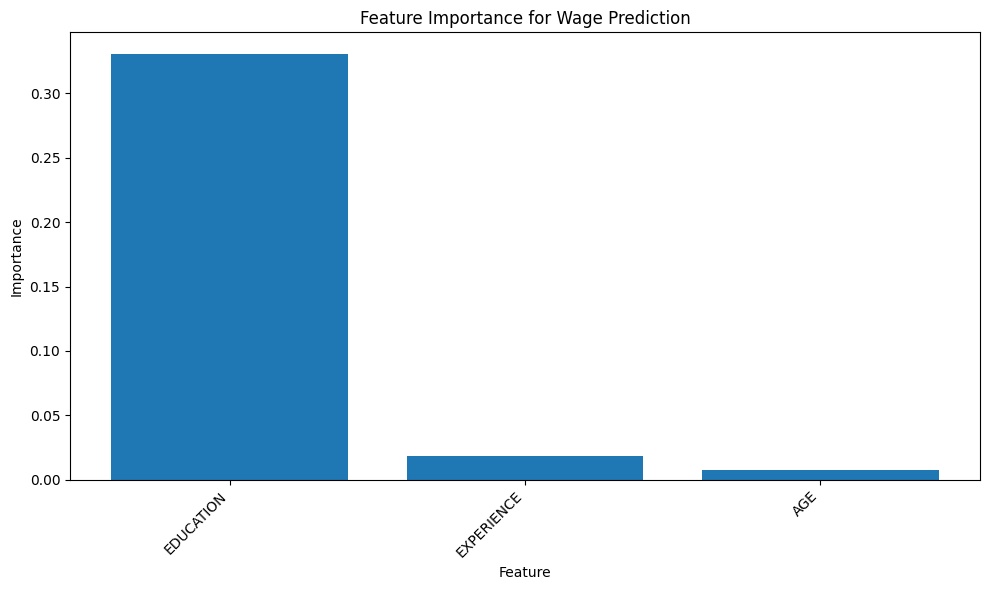

In [6]:
# Visualization
plt.figure(figsize=(10, 6))
plt.bar(importance['feature'], importance['importance'])
plt.xticks(rotation=45, ha='right')
plt.title('Feature Importance for Wage Prediction')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

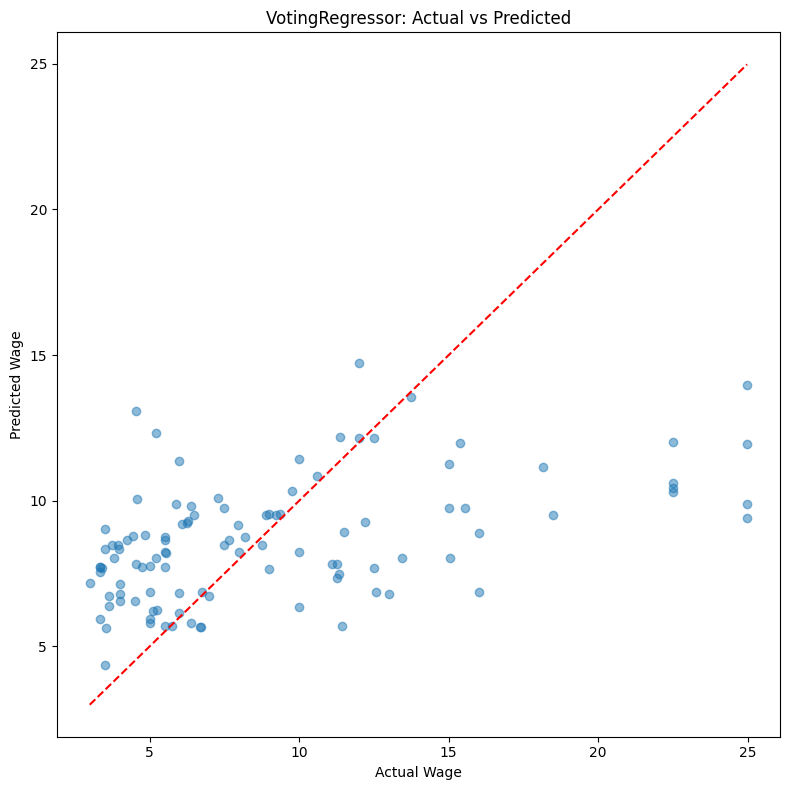

In [7]:
# Compare predictions
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_voting, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Wage')
plt.ylabel('Predicted Wage')
plt.title('VotingRegressor: Actual vs Predicted')
plt.tight_layout()
plt.show()